<a href="https://colab.research.google.com/github/nasif-raihan/GSU/blob/main/CSCI_7090_Module4_Lab2_DecisionTreeRegression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Module 4 — Decision Tree Regression (Lab)
**Computer Vision · Machine Learning for Vision**

A decision tree can also predict continuous values. We fit one to a noisy sine curve and see its characteristic **piecewise-constant** prediction.

## 1. Imports & a synthetic dataset

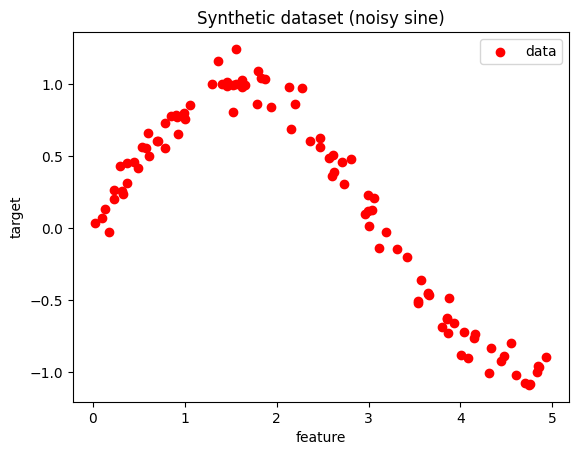

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

np.random.seed(42)
X = np.sort(5 * np.random.rand(100, 1), axis=0)
y = np.sin(X).ravel() + np.random.normal(0, 0.1, X.shape[0])

plt.scatter(X, y, color="red", label="data")
plt.title("Synthetic dataset (noisy sine)"); plt.xlabel("feature"); plt.ylabel("target"); plt.legend(); plt.show()

## 2. Split, fit, evaluate

In [2]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
reg = DecisionTreeRegressor(max_depth=4, random_state=42)
reg.fit(X_train, y_train)
y_pred = reg.predict(X_test)
print("Mean Squared Error:", round(mean_squared_error(y_test, y_pred), 4))

Mean Squared Error: 0.0151


## 3. Visualize the prediction
Note the **stair-step** shape — a tree predicts a constant value within each leaf's region.

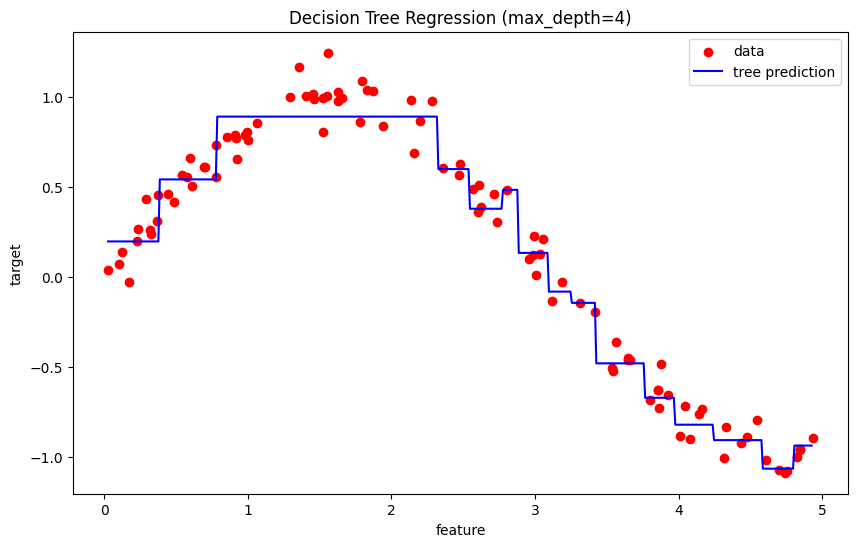

In [3]:
X_grid = np.arange(X.min(), X.max(), 0.01)[:, np.newaxis]   # X.min()/X.max(), not min(X)
y_grid = reg.predict(X_grid)

plt.figure(figsize=(10, 6))
plt.scatter(X, y, color="red", label="data")
plt.plot(X_grid, y_grid, color="blue", label="tree prediction")
plt.title("Decision Tree Regression (max_depth=4)"); plt.xlabel("feature"); plt.ylabel("target"); plt.legend(); plt.show()

## 4. Effect of depth (overfitting)
A deeper tree chases the noise; a shallow tree underfits. Compare.

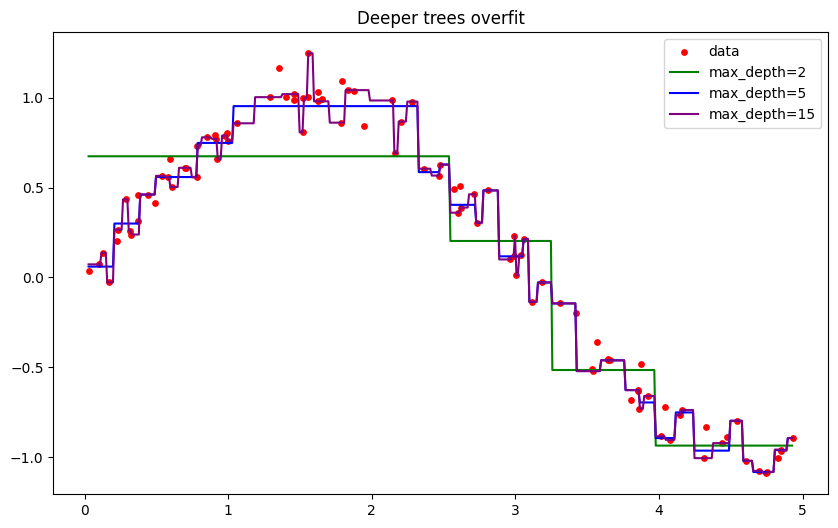

In [4]:
plt.figure(figsize=(10, 6)); plt.scatter(X, y, color="red", s=15, label="data")
for d, col in [(2, "green"), (5, "blue"), (15, "purple")]:
    m = DecisionTreeRegressor(max_depth=d, random_state=42).fit(X_train, y_train)
    plt.plot(X_grid, m.predict(X_grid), color=col, label=f"max_depth={d}")
plt.title("Deeper trees overfit"); plt.legend(); plt.show()

## 5. Visualize the tree structure

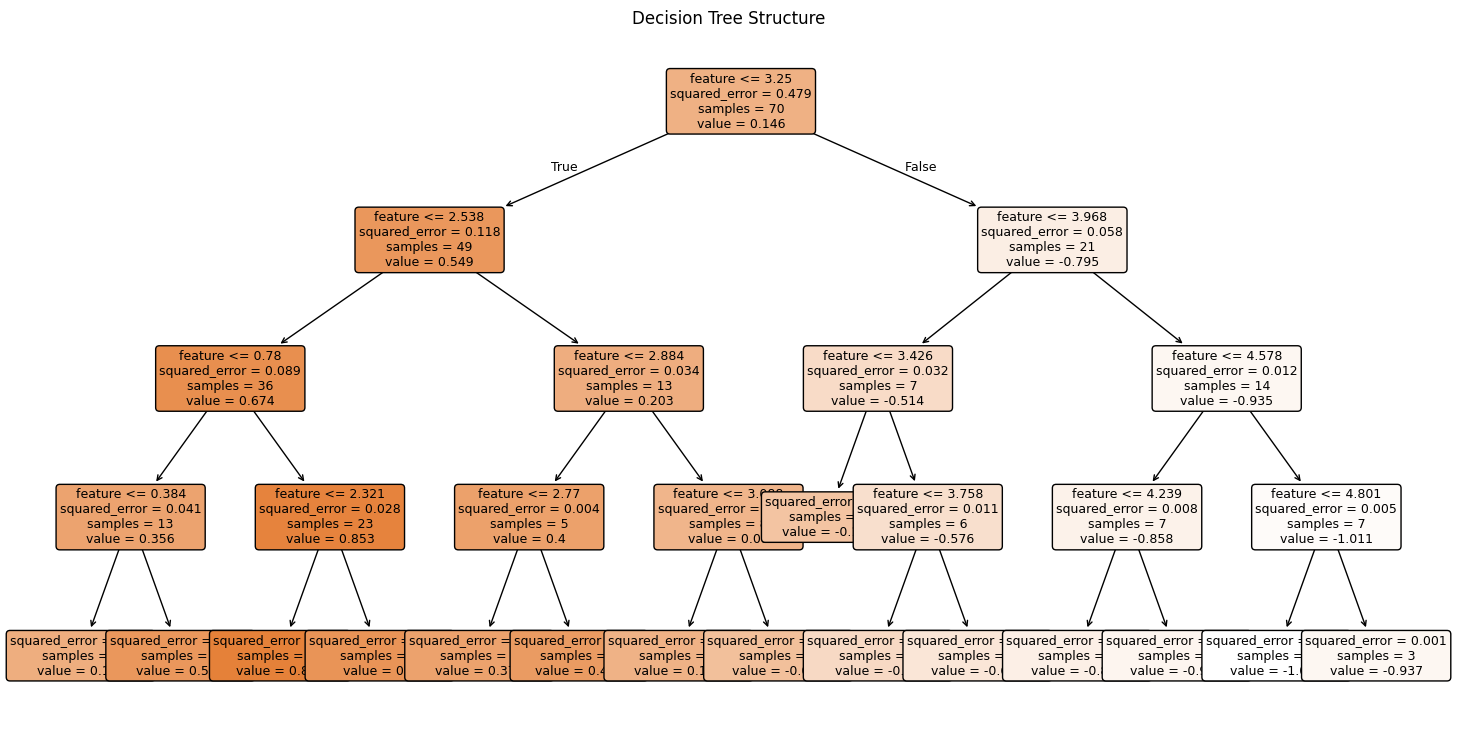

In [5]:
plt.figure(figsize=(18, 9))
plot_tree(reg, feature_names=["feature"], filled=True, rounded=True, fontsize=9)
plt.title("Decision Tree Structure"); plt.show()